In [1]:
import sys
import os
import copy
from os import path, getcwd
from collections import OrderedDict
import warnings
import torch

from scipy.stats import wasserstein_distance, kstest, norm, multivariate_normal, uniform
from torch.distributions import MultivariateNormal
import seaborn as sns
from matplotlib import pyplot as plt, ticker as mticker
from matplotlib.lines import Line2D
from IPython.display import clear_output

EVAL_DATASET_SIZE = 2**13
#EVAL_DATASET_SIZE = 2**12
ROOT = 'C:/Mega/trunk/master-thesis'
DATA_PATH = 'F:/master_data/'
CUDA = True

# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

%reload_ext autoreload
%autoreload 2

from precomputation.initialization import *
from misc.naming import *
from inflation.jupyter_helper import *
from misc.common_functions import *


folder = 'inflation-04.04_11-55-40-smooth_step-exp'
#folder = 'inflation-04.04_16-54-31-line-exp'
#folder = 'inflation-07.12_11-09-45-sphere-exp_-batch=32'

# uniform
#folder = 'uniform/inflation-09.13_11-27-54-smooth_step-exp_uniform_noise'
#folder = 'uniform/inflation-09.13_00-20-23-line-exp_uniform_noise'

# comparison
folder = 'comparison_ss'
#folder = 'comparison_line'
#folder = 'comparison_sphere'

if 'line' in folder:
    EVAL_DATASET_SIZE *= 2

CHECKPOINTS_ROOT = f'{DATA_PATH}/checkpoints/{folder}'

PLOT_MODE = 'uni_normal_compare' # uni_normal_compare uniform 'no_volume' 'ss_show', 'rest'
if PLOT_MODE == 'no_volume':
    MODEL_SORTING = ('RealNVP', 'RealNC', 'true')
elif PLOT_MODE == 'ss_show':
    MODEL_SORTING = ('NICE', 'RealVP', 'RealNVP', 'true')
elif PLOT_MODE == 'rest':
    MODEL_SORTING = ('NICE', 'RealVP', 'RealNVP', 'true') # 'ResFlow', 'RealNC',
elif PLOT_MODE == 'uniform':
    MODEL_SORTING = ('NICE', 'RealVP', 'RealNVP', 'true')
elif PLOT_MODE == 'uni_normal_compare':
    MODEL_SORTING = ('NICE', 'NICE_uniform', 'RealVP', 'RealVP_uniform', 'RealNVP', 'RealNVP_uniform', 'true')
    
DATASET_NAME = None

DATASET_EXTENSION = create_dataset_extension(folder)
if PLOT_MODE == 'no_volume':
    DATASET_EXTENSION += 'no_volume_mode'
elif PLOT_MODE == 'ss_show':
    DATASET_EXTENSION += 'ss_show'
elif PLOT_MODE == 'uni_normal_compare':
    DATASET_EXTENSION += 'uni_normal_compare'

ADD_GAUSS_MODEL = 'gauss' not in folder
ADD_GAUSS_MODEL = False
if ADD_GAUSS_MODEL:
    MODEL_SORTING = (*MODEL_SORTING, 'N(0,1)')

IGNORE_DEFLATION = True  # automatically ignored for gauss data
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
#all_checkpoints

In [3]:
all_checkpoints = get_all_checkpoints(CHECKPOINTS_ROOT)
all_checkpoints_unsorted = all_checkpoints

all_checkpoints = sort_all_checkpoints(all_checkpoints, DATA_PATH)
dimensions, variances = get_all_dimensions_and_variances(all_checkpoints)

# to load some standard information
config = load_config(all_checkpoints['NICE'][dimensions[0]][variances[0]], DATA_PATH, verbose=False)

# Dataset name
DATASET_NAME = dataset_to_name(config.dataset)
if DATASET_EXTENSION != '':
    DATASET_NAME += '_' + DATASET_EXTENSION

models_to_delete = ['ResFlow', 'RealVP', 'NICE_uniform', 'RealVP_uniform', 'RealNVP_uniform']
for model_to_del in models_to_delete:
    if model_to_del not in MODEL_SORTING:
        del all_checkpoints[model_to_del]
    
RES_FLOW_CONTAINED = 'ResFlow' in all_checkpoints

In [4]:
#all_checkpoints

In [5]:
config

Namespace(training_class=-1, model='2d_nf', debug=False, data_path='F:/master_data/datasets', seed=42, root='F:\\master_data\\', own_folder='inflation-04.04_14-25-00-2d-smooth_step', load_checkpoint=None, num_samples=24, sample_every=None, overfit=False, no_bias=False, early_stopping=100, wandb_name_ext='2d_nf_-samples=1000', adjust_prior_var=False, manifold_evaluation=10, pdf_evaluation=None, adjust_scaling_weights=False, trainable_scaling=None, normal_init_trainable_scale=True, inflation=True, var=None, uniform_noise=None, dimensions=2, train_size=1000, even_spreadout=False, no_rotation=False, list_dimension=True, skip_scaling=False, sphere_radius=0, mises_kappa=6.0, line_length=1.0, x_start=-15.0, x_end=20.0, growth_rate=1.0, data_start=-5.0, data_end=5.0, data_offset=1.0, data_range=10.0, data_growth=0.5, epochs=1001, device='cuda', parallel=None, resume=None, name=None, eval_every=10, dont_check=False, log_wandb=False, dataset='smooth_step', batch_size=32, eval_batch_size=256, num

In [6]:
#dimensions = np.array([36])#36, 100, 196])
#dimensions = np.array([36, 100, 196])
#variances = np.array([1e-6, 1e-4])

#variances = variances[1:3]
#variances = variances[0:2]

if PLOT_MODE == 'uni_normal_compare':
    variances = variances[variances != 0]


[model] [dimensions] [var] ['ambient', 'manifold'] [keys] 

In [7]:
%matplotlib inline
all_models = load_and_sort_all_data(all_checkpoints, variances, dimensions, DATA_PATH, 
                                    eval_dataset_size=EVAL_DATASET_SIZE, experiment='inflation',
                                    data_extension=DATASET_EXTENSION, add_gauss_model=ADD_GAUSS_MODEL, 
                                    ignore_deflation=IGNORE_DEFLATION, normalize_realnc=False)

remove_z_idx(all_models)

Loading / Storing Data from
F:/master_data/preloaded_experiments\inflation-smooth_step-uni_normal_compare\dim2-var-6.0.exp
 dim 196 var 0.1  1 

C:/Mega/trunk/master-thesis\src/exp\inflation\jupyter_helper.py:109: UserWarning: This should be reconsidered, when X is not bounded! (Like z ~ N)
  warnings.warn('This should be reconsidered, when X is not bounded! (Like z ~ N)')


-------------------
# Plots
# Distances


In [8]:
%matplotlib inline

KL_DIV_RATIO = 1/2 # 3/5 #2/3
def approx_distance_between_prior_and_data_state_dens(dim, true_pd):
    # sample state density from prior
    samples_prior = norm.rvs(size=(dim, 100000))
    logpdf_prior = norm.logpdf(samples_prior).sum(0)
    
    # as prior is flexible, shift mean of prior to where mean of true_pd is
    logpdf_prior_meanshift = logpdf_prior - logpdf_prior.mean() + true_pd.mean()
    
    distance = wasserstein_distance(logpdf_prior_meanshift, true_pd)
    return distance


def mark_distance_if_ratio_greater_threshold(real_nvp_vals, nice_vals, model, ax):
    assert MODEL_SORTING.index('RealNVP') - MODEL_SORTING.index('NICE') == 1, 'RealNVP must come before NICE'
    
    if model == 'RealNVP':
        min_val = np.minimum(real_nvp_vals, nice_vals)
        max_val = np.maximum(real_nvp_vals, nice_vals)
        ratios = min_val / max_val
        
        ratio_exceeded = ratios < KL_DIV_RATIO
        
        # to plot for the var=0 case as well
        var_with_0 = np.copy(variances)
        var_with_0[var_with_0 == 0] = variances[variances > 0].min() * 0.5
        
        ax.scatter(var_with_0[ratio_exceeded], min_val[ratio_exceeded], marker='x', s=100, color='g')
        

def set_y_lims_by_tests(axes, tests):
    """Sets fixed axes y-limits"""
    """fixed_y_limits_smooth_step = dict(kl=(7.8e-04, 2.4e+00), wasserstein=(1.1e-03, 3.4e+00), kl_mani=(2.9e-04, 4.1e-01), 
                                      dos_mani=(5.5e-02, 3.6e+00), mmd=(6.0e-04, 7.7e-01))

    fixed_y_limits_uniform = dict(kl=(2.1e-04, 2.0e+00), wasserstein=(8.1e-04, 2.4e+00), kl_mani=(6.6e-06, 8.7e-02), 
                                      dos_mani=(1.7e-02, 3.3e+00), mmd=(1.9e-04, 9.6e-01))
    
    fixed_y_limits_mises = dict(kl=(2.1e-04, 2.0e+00), wasserstein=(8.1e-04, 2.4e+00), kl_mani=(6.6e-06, 4.3e-01), 
                                      dos_mani=(1.7e-02, 3.3e+00), mmd=(1.9e-04, 9.6e-01))"""
    global TRANSPOSE
    one_to_fix_them_all = dict(kl=(8.6e-04, 2.4e+00), wasserstein=(7.3e-04, 3.4e+00), kl_mani=(8.1e-05, 4.3e-01), 
                                      dos_mani=(3.6e-02, 3.6e+00), mmd=(1.9e-04, 9.6e-01))


    fixed_y_limits_smooth_step = fixed_y_limits_uniform = fixed_y_limits_mises = one_to_fix_them_all

    
    if PLOT_MODE in ['uniform', 'uni_normal_compare']:
        fixed_y_limits_smooth_step = dict(kl=(7.8e-04, 5e+01), wasserstein=(9.7e-04, 3.4e+00), kl_mani=(2.9e-04, 4.1e-01), 
                                      dos_mani=(5.5e-02, 3.6e+00), mmd=(6.0e-04, 7.7e-01))  

    y_limits_by_dataset = {'smooth_step': fixed_y_limits_smooth_step,
                          'line': fixed_y_limits_uniform,
                          'sphere': fixed_y_limits_mises}
    
    """
    """
    if config.dataset not in y_limits_by_dataset:
        print('no limits were set! / Limits are')
        for y, test in enumerate(tests):
            for x in range(len(axes[y])):
                computed_ylim = axes[y, x].own_y_lims
                print(f'{test} {0.9*computed_ylim[0]:.1e}, {1.1*computed_ylim[1]:.1e}')
        return
    
    y_limits_by_test = y_limits_by_dataset[config.dataset]
    for y, test in enumerate(tests):
        fixed_limit = y_limit = y_limits_by_test[test]
        limited_exceeded = False
        for x in range(len(axes[y])):
            if TRANSPOSE:
                computed_ylim = axes[x, y].own_y_lims
            else:
                computed_ylim = axes[y, x].own_y_lims
                
            if computed_ylim[0] < y_limit[0] or computed_ylim[1] > y_limit[1]:
                y_limit = min(computed_ylim[0]*0.9, y_limit[0]), max(computed_ylim[1]*1.1, y_limit[1])
                limited_exceeded = True
            if TRANSPOSE:
                axes[x, y].set_ylim(fixed_limit)
            else:
                axes[y, x].set_ylim(fixed_limit)
            
        if limited_exceeded:
            print(f'Exceeded limit for {test} | New limit {y_limit[0]:.1e}, {y_limit[1]:.1e}')
    
            
def store_limits_in_axes(ax, y_vals):
    y_vals = np.array(y_vals)
    y_vals = y_vals[y_vals != None]
    if 'own_y_lims' in dir(ax):
        old_min, old_max = ax.own_y_lims    
        ax.own_y_lims = min(old_min, y_vals.min()), max(old_max, y_vals.max())
    else:
        ax.own_y_lims = y_vals.min(), y_vals.max()
        
        
def plot_benchmark(ax, test, dim, non_zero_var, linewidth):
      #print(test, model, dim, var)
    if test in ['kl', 'kl_mani', 'wasserstein', 'dos_mani']:
        baseline = []
        for var in non_zero_var:
            log_p = all_models['true'][dim][var]['ambient']['dataset'].densities[INFLATED_MANIFOLD_LOG_PD]
            x = all_models['true'][dim][var]['ambient']['none_embedded_data'][:, 0]
            base_params = dict(scale=np.sqrt(x.var()), loc=x.mean())
            
            if test == 'kl':
                log_p = all_models['true'][dim][var]['ambient'][PD_IDX]
                x = all_models['true'][dim][var]['ambient'][EMBEDDED_DATA]
                flat_x = x.reshape((len(x), -1))
                mvn = MultivariateNormal(flat_x.mean(0), covariance_matrix=flat_x.var(0) * torch.eye(flat_x.shape[1]))
                log_q = mvn.log_prob(flat_x).numpy()
                baseline.append(np.mean(log_p - log_q) / dim)
            elif test in ['kl', 'kl_mani']:
                log_q = norm.logpdf(x, **base_params)
                baseline.append(np.mean(log_p - log_q))
            elif test in ['wasserstein', 'dos_mani']:
                log_q = norm.logpdf(norm.rvs(size=len(log_p), **base_params), **base_params)
                dist = wasserstein_distance(log_p, log_q)
                if test == 'wasserstein':
                    dist /= dim
                baseline.append(dist)
                
        print(baseline)
        ax.plot(non_zero_var, baseline, 'o-', color='black', label='baseline', linewidth=0.5, alpha=1)

TRANSPOSE = True
def plot_difference_of_density_states(tests=[], save_path=None, y_top=None, manifold_stuff=False, print_model_scores=False):
    global TRANSPOSE
    print('plotting ' + config.dataset)

    
    if TRANSPOSE:
        test_to_label = {'wasserstein': 'Wasserstein of DoS / $D$', 'wasser_mean': 'Wassers Mean of DoS', 'mmd': '√MMD Distance of DoS',
                     'kl_mani': 'KL Div on Manifold', 'llh_mani': 'BPD on Manifold', 'dos_mani': 'Wasserstein of\nManifold DoS'}
    else:
        test_to_label = {'wasserstein': 'Wasserstein\nof DoS / $D$', 'wasser_mean': 'Wassers Mean\nof DoS', 'mmd': '√MMD Distance\nof DoS',
                     'kl_mani': 'KL Div\non Manifold', 'llh_mani': 'BPD\non Manifold', 'dos_mani': 'Wasserstein of\nManifold DoS'}
    test_to_label.update({'kl': 'KL Div / $D$'})

    if len(tests) == 1:
        print(test_to_label[tests[0]])
    
    #  'wasser_mean': 'Wasserstein Meaned\nof DoS',  #, 'dos_mani': 'Wasserstein of\nManifold DoS'} 'loss': 'Loss'
    PLOT_MODE == 'uni_normal_compare'
    DPI = 80 # 150
    if TRANSPOSE:
        #y_size = 2.5 * len(tests) if len(dimensions) > 1 else 2 * len(tests) + 5
        y_size = 2.5 * len(dimensions) if len(tests) > 1 else 2 * len(dimensions) + 5
        fig, axs = plt.subplots(nrows=len(dimensions), ncols=len(tests), sharey='col',
                                squeeze=False, figsize=(len(tests)*7, y_size), dpi=DPI)
    else:
        y_size = 2.5 * len(tests) if len(dimensions) > 1 else 2 * len(tests) + 5
        fig, axs = plt.subplots(nrows=len(tests), ncols=len(dimensions), sharey='row',
                                squeeze=False, figsize=(len(dimensions)*7, y_size), dpi=DPI)

    none_zero_var = variances != 0
    
    x_axis_font_size = 15
    text_size = 18
    
    if 'llh_mani' in tests:
        print('BPD: -llh / (dim * log(2))')
    if 'dos_mani' in tests and 'Uniform' in DATASET_NAME:
        print('Wasserstein distance has a problem with dirac distributions, thus DoS on manifold with var=0 can not be computed.')
    
    #no_zero_var = not any([zero_var_test in tests for zero_var_test in ['kl_mani', 'dos_mani']])
    
    all_distances = dict()
    for i, test in enumerate(tests):
        all_distances[test] = dict()
        # wasserstein, as we would be comparing different dimensional distributions
        has_zero_var_value = test not in ['wasserstein','mmd', 'kl']  and PLOT_MODE not in ['uniform', 'uni_normal_compare']
        #if 0 in variances and test not in ['kl', 'wasserstein']:
            
        for iD, dim in enumerate(dimensions):
            all_distances[test][dim] = dict()
            #if dim != 36: break
            ax = axs[iD, i] if TRANSPOSE else axs[i, iD]
            
            previous_distance_array = None
            for model in MODEL_SORTING:
                # if test == loss and model == true thats okay. All other true_model parts will be skipped
                
                # needed for entropy
                if (model == 'true' and test not in ['loss']) \
                    or (model in ['RealNC', 'ResFlow'] and test == 'wasserstein'):
                    continue
                    
                if 'RealVP' in model and dim == 2: continue  # coincides with NICE

                y_values = []
                for iS, var in enumerate(variances):
                    distance = None
                    # distances for var == 0 does not make sense everywhere
                    if var == 0 and not has_zero_var_value:
                        y_values.append(None)
                        continue
                    
                    #print(test, model, dim, var)
                    if test == 'kl_mani':
                        data_idx, pd_idx = 'manifold', CORRECTED_PD
                    elif test == 'llh_mani':
                        data_idx, pd_idx = 'manifold', PD_IDX
                    else:
                        data_idx, pd_idx = 'ambient', PD_IDX
                    
                    model_pd = all_models[model][dim][var][data_idx][pd_idx]
                    true_pd = all_models['true'][dim][var][data_idx][pd_idx]

                    if 'wasser' in test:
                        model_pd = all_models[model][dim][var]['model_densities']
                        
                    if test == 'wasserstein':
                        #if model == 'true':
                        #    distance = None if var == 0 else approx_distance_between_prior_and_data_state_dens(dim, true_pd)
                        #else:
                        distance = wasserstein_distance(true_pd / dim, model_pd / dim)
                        #distance = wasserstein_distance(true_pd, model_pd)
                    elif test == 'wasser_mean':
                        if model  == 'NICE':
                            distance = wasserstein_distance(true_pd / dim, (model_pd - model_pd.mean() + true_pd.mean()) / dim)
                        else:
                            distance = wasserstein_distance(true_pd / dim, model_pd / dim)
                    elif test == 'mmd':
                        model_pd = all_models[model][dim][var]['model_densities'] / dim
                        normed_true_pd = true_pd.mean() / (dim if var > 0 else 1)
                        distance = np.abs(normed_true_pd - model_pd.mean())
                    elif test == 'kl' or test == 'kl_mani':
                        distance = np.mean(true_pd - model_pd) / dim
                    elif test == 'kl_mani':
                        distance = np.mean(true_pd - model_pd)
                    #elif test == 'loss':
                    #    distance = -model_pd.mean()
                    elif test == 'llh_mani':
                        distance = -model_pd.mean() / (np.log(2) * dim)
                    elif test == 'dos_mani':
                        model_logpdf = all_models[model][dim][var]['manifold_grid'][CORRECTED_PD]
                        m = all_models['true'][dim][var]['manifold_grid']['dataset'].data[INFLATED_MANIFOLD_DATA]
                        sampled_true_manifold = all_models['true'][dim][var]['manifold']['dataset'].densities[INFLATED_MANIFOLD_LOG_PD]

                        sampled_model_manifold = create_dos_samples_of_manifold(model_logpdf, m, 10000)
                        distance = wasserstein_distance(sampled_model_manifold, sampled_true_manifold)

                    # normal case
                    y_values.append(distance)
                            
                y_values = np.array(y_values)
                all_distances[test][dim][model] = y_values
                #best_distance = y_values.argmin()
                non_zero_var = variances[none_zero_var]
                non_zero_scores = y_values[none_zero_var]
                
                color = get_model_color(model)
                if test == 'loss':
                    label = 'H(p)' if model == 'true' else f'H(p, {model})'
                else:
                    label = get_model_name(model, comparison_mode=(PLOT_MODE=='uni_normal_compare'))
                    
                line_style = '-' if 'uniform' not in model else '--' #linestyle=line_style,  marker='o', linestyle=line_style,
                style = '-o' if 'uniform' not in model else '--x'
                legend = ax.plot(non_zero_var, non_zero_scores, style, color=color, label=label, linewidth=0.8, alpha=1)
                store_limits_in_axes(ax, y_values)
                if any(np.logical_not(none_zero_var)):
                    # plots the sigma = 0 point
                    zero_var_x = variances[none_zero_var].min() * 0.3
                    if has_zero_var_value:
                        ax.plot(zero_var_x, y_values[np.logical_not(none_zero_var)], marker='o', markersize=4, color=color)
                    elif not TRANSPOSE:
                        # this is a dummy entry, s.t. the plots match
                        ax.plot(zero_var_x, y_values[none_zero_var][0], alpha=0)                        
                #if test == 'kl':
                    #mark_distance_if_ratio_greater_threshold(y_values, previous_distance_array, model, ax)
                    #previous_distance_array = y_values
            #plot_benchmark(ax, test, dim, non_zero_var, linewidth)
            ax.set_xscale('log')
            
            """if has_zero_var_value:
                ax.set_xticks([variances[none_zero_var].min() / 10] + list(variances[none_zero_var]))
            else:
            """
            ax.set_xticks(variances[none_zero_var])
                
            ax.tick_params(axis='x', which='minor', bottom=False)
            
            if TRANSPOSE:
                if i == 0 and (not len(tests) == 1 or config.dataset == 'smooth_step'):
                    ax.set_ylabel(f'$D$ = {dim}', size=16)
                if iD == 0 and len(tests) > 1:
                    ax.set_title(test_to_label[test], size=18)
                if iD == len(dimensions) - 1:
                    ax.set_xlabel('$σ^2$', fontsize=text_size) # at bottom
            else:
                if iD == 0:
                    ax.set_title(f'$D$ = {dim}', size=18)
                if i == 0:
                    ax.set_ylabel(test_to_label[test], size=16)
                if i == len(tests) - 1:
                    ax.set_xlabel('$σ^2$', fontsize=text_size) # at bottom
                    
            ax.yaxis.set_tick_params(labelbottom=True)
            ax.yaxis.set_major_locator(mticker.LogLocator(numticks=999))
            ax.yaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs=(.2, .4, .6, .8)))
            
            ax.tick_params(axis='both', which='major', labelsize=x_axis_font_size)
            
            #if 0 in variances and test not in ['kl', 'wasserstein']:
            if has_zero_var_value:
                ax.annotate('0', xy=(0.055, -0.06), ha='right', va='top', xycoords='axes fraction', fontsize=x_axis_font_size)
                
            if test == 'llh_mani':
                ...
            elif test != 'loss':
                ax.set_yscale('log')  #'symlog'
            
            # small horizontal lines
            ax.grid(True, axis='y', alpha=0.6)
    set_y_lims_by_tests(axs, tests)
    
    # if only one test => dataset should be the last 
    #if len(tests) != 1 or config.dataset == 'sphere':
    #if (TRANSPOSE and config.dataset == 'line') or (not TRANSPOSE and config.dataset == 'sphere') or len(tests) > 1:
    legend_plotter(fig, axs, tests, dimensions, save_path)
    #plt.suptitle(f'{DATASET_NAME}', fontweight='bold', size=text_size)
        
    save_inflation_fig(fig, save_path, config.dataset, dimensions, DATASET_EXTENSION)
    return all_distances

def export_legend(legend, save_path):
    #print(type(legend))
    #print(dir(legend))
    fig = legend.figure
    fig.canvas.draw()
    bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    path = get_inflation_fig_save_path(save_path, '', dimensions, DATASET_EXTENSION)
    fig.savefig(path + 'legend.pdf', format='pdf', bbox_inches=bbox)
    #save_inflation_fig(fig, save_path, 'legend', dimensions, DATASET_EXTENSION)
    
def legend_plotter(fig, axs, tests, dimensions, save_path):
    global TRANSPOSE
    row_count = len(dimensions) if TRANSPOSE else len(tests)
    # plot only one legend in this case
    handles, labels = axs[-1, -1].get_legend_handles_labels()
    if row_count == 1:
        bbox_to_anchor = (0.5, -0.4)
    elif row_count == 2:
        bbox_to_anchor = (0.5, -0.2)
    elif row_count == 3:
        bbox_to_anchor = (0.5, -0.15)
    elif len(MODEL_SORTING)-1 == 2: # RealNC case / true is always contained
        bbox_to_anchor = (0.5, -0.09)
    elif PLOT_MODE == 'uni_normal_compare':
        bbox_to_anchor = (0.5, -0.07) 
    else:
        bbox_to_anchor = (0.5, -0.01)
    legend = fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=20, bbox_to_anchor=bbox_to_anchor)
    export_legend(legend, save_path)
    legend.remove()
    return legend
    
#plot_difference_of_density_states(save_path='distances', tests=['kl'])
#  uni_normal_compare uniform 'no_volume' 'ss_show', 'rest'
#_=plot_difference_of_density_states(tests=['kl', 'kl_mani'], print_model_scores=True)
#all_distances = plot_difference_of_density_states(save_path='used/kl_wasser', tests=['kl', 'wasserstein'], print_model_scores=False)
#_=plot_difference_of_density_states(tests=['kl_mani'], print_model_scores=False)
#_=plot_difference_of_density_states(save_path='used/div/kl', tests=['kl'], print_model_scores=True)

In [9]:
if PLOT_MODE in ['ss_show', 'rest']:
    all_distances = plot_difference_of_density_states(save_path='used/div/all', tests=['kl', 'kl_mani', 'wasserstein', 'dos_mani'], print_model_scores=True)

In [10]:
if PLOT_MODE in ['ss_show', 'rest']:
    plot_difference_of_density_states(save_path='used/div/kl', tests=['kl'], print_model_scores=True)

In [11]:
if PLOT_MODE in ['ss_show', 'rest']:
    plot_difference_of_density_states(save_path='used/div/kl_mani', tests=['kl_mani'], print_model_scores=True)

In [12]:
if PLOT_MODE in ['ss_show', 'rest']:
    plot_difference_of_density_states(save_path='used/div/wasserstein', tests=['wasserstein'], print_model_scores=True)

In [13]:
if PLOT_MODE in ['ss_show', 'rest']:
    plot_difference_of_density_states(save_path='used/div/dos_mani', tests=['dos_mani'], print_model_scores=True)

In [14]:
#if PLOT_MODE in ['ss_show', 'rest'] and config.dataset == 'smooth_step':
#    all_distances = plot_difference_of_density_states(save_path='used/kl_wasser', tests=['kl', 'wasserstein'], print_model_scores=False)

In [15]:
#if PLOT_MODE in ['ss_show', 'rest'] and config.dataset == 'smooth_step':
#    all_distances = plot_difference_of_density_states(save_path='used/mani_kl_wasser', tests=['kl_mani', 'dos_mani'], print_model_scores=False)

In [16]:
#if PLOT_MODE == 'no_volume':
#    all_distances = plot_difference_of_density_states(save_path='used/div/volume_element', tests=['kl', 'kl_mani'], print_model_scores=True)

In [17]:
if PLOT_MODE == 'no_volume':
    all_distances = plot_difference_of_density_states(save_path='used/div/no_volume_kl', tests=['kl'], print_model_scores=True)

In [18]:
if PLOT_MODE == 'no_volume':
    all_distances = plot_difference_of_density_states(save_path='used/div/no_volume_kl_mani', tests=['kl_mani'], print_model_scores=True)

plotting smooth_step
Exceeded limit for kl | New limit 7.8e-04, 8.1e+02


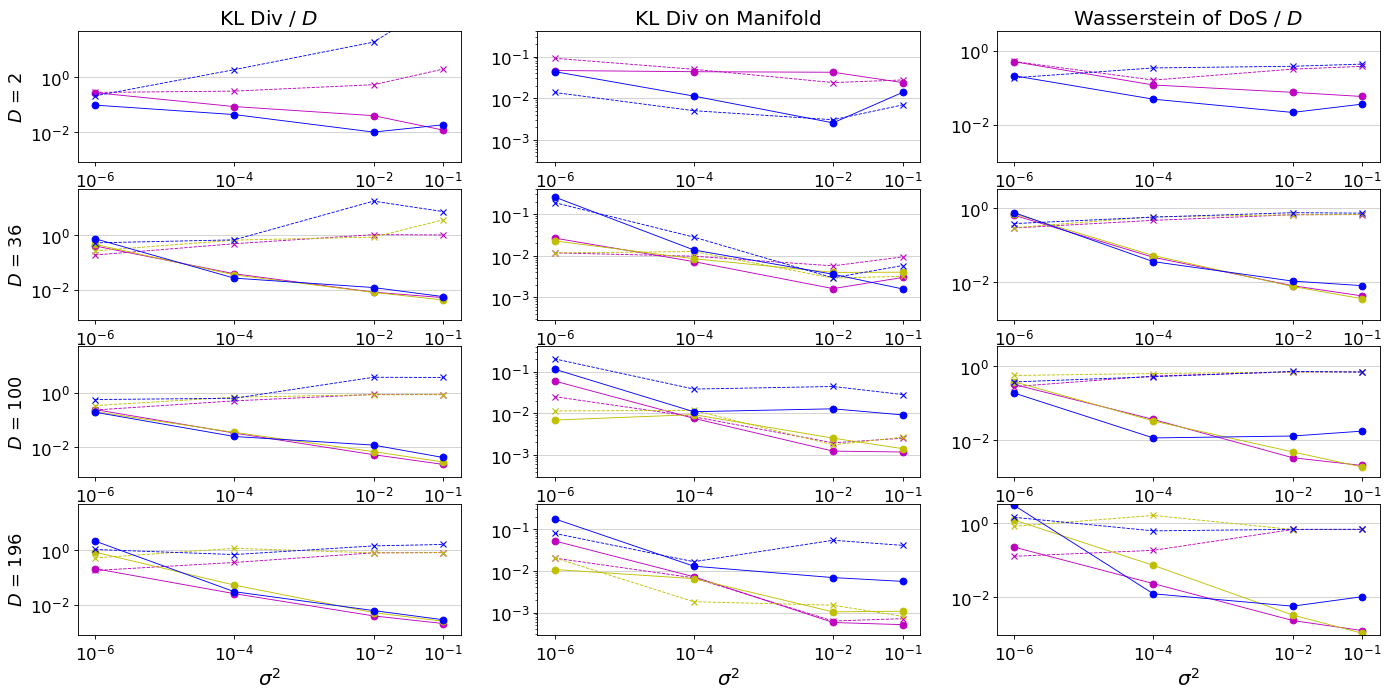

In [19]:
if PLOT_MODE in ['uniform', 'uni_normal_compare']:
    all_distances = plot_difference_of_density_states(save_path='used/div/uni_normal_cmp', tests=['kl', 'kl_mani', 'wasserstein'], print_model_scores=True)

In [106]:
#error!@@@

-----------------------------------
# Distance Evaluation

In [300]:
def compute_uni_normal_compare_score(all_distances, better_at_least=.1):        
    print(DATASET_NAME)
    print('normal\nuniform')
    
    none_zero_var = variances != 0
    down_grader = 1 - better_at_least
    for test in all_distances.keys():
        #if test not in ['kl', 'kl_mani']: continue
        print('\n', test)
        for current_model in all_distances[test][36].keys():
            if 'uniform' in current_model:
                continue

            total_trials = 0
            score_normal_better = 0
            score_uni_better = 0
            for dim in all_distances[test].keys():
                if current_model not in all_distances[test][dim].keys():
                    continue
                    
                normal_better = all_distances[test][dim][current_model][none_zero_var] < \
                                    down_grader * all_distances[test][dim][current_model+'_uniform'][none_zero_var]
                uni_better = all_distances[test][dim][current_model+'_uniform'][none_zero_var] < \
                                    down_grader * all_distances[test][dim][current_model][none_zero_var]
                score_normal_better += normal_better.sum()
                score_uni_better += uni_better.sum()
                total_trials += len(none_zero_var)

            print(current_model)
            print(score_normal_better / total_trials)
            print(score_uni_better / total_trials)
            
                    
def compute_model_score(all_distances, better_at_least=.1):
    """Prints which model performed best"""
    down_grader = 1 - better_at_least
    none_zero_var = variances != 0
    print(DATASET_NAME)
    for test in all_distances.keys():
        if test not in ['kl', 'kl_mani']: continue
        print('\n---------------------------------------------------------\n', test)
        for dim in all_distances[test].keys():
            print('\nDim:', dim)
            VP_score = 0
            models_names = all_distances[test][dim].keys()
            if PLOT_MODE == 'rest':
                
                real_nvp = all_distances[test][dim]['RealNVP'][none_zero_var]
                real_vp = all_distances[test][dim]['RealVP' if dim > 2 else 'NICE'][none_zero_var]
                nice = all_distances[test][dim]['NICE'][none_zero_var]
                
                real_nvp_score = np.logical_and(real_nvp < (down_grader * real_vp), real_nvp < (down_grader * nice)).sum()
                vp_score = np.logical_and(real_vp < (down_grader * real_nvp), nice < (down_grader * real_nvp)).sum()
                print('RealNVP', real_nvp_score)
                print('VP', vp_score)
            else:
                for current_model in models_names:
                    current_model_distances = all_distances[test][dim][current_model][none_zero_var]
                    is_best = current_model_distances == current_model_distances

                    # compare to other models
                    for other_model in set(models_names).difference({current_model}):
                        other_distances = all_distances[test][dim][other_model][none_zero_var]
                        is_best = np.logical_and(is_best, (1-better_at_least) * current_model_distances < other_distances)
                    print(f'{current_model}\t{is_best.sum()}')
                    if current_model in ['NICE', 'RealVP']:
                        VP_score += is_best.sum()
                print(f'VP\t{VP_score}')
            
            
def whole_space_better_but_manifold_not(all_distances, better_at_least=.1):
    print('######################################################')
    print('Better in whole space and worse on manifold\n', 'FP / (FP + TP)')
    print(DATASET_NAME, '\n')
    
    none_zero_var = variances != 0
    down_grader = 1 - better_at_least
    for dim in all_distances['kl'].keys():
        print('\nDim:', dim)
        model_names = all_distances['kl'][dim].keys()
        for current_model in model_names:
            if current_model == 'RealNC': continue
            current_whole_space = all_distances['kl'][dim][current_model][none_zero_var]
            current_mani = all_distances['kl_mani'][dim][current_model][none_zero_var]
            
            better_in_whole_and_worse_in_mani = 0
            total_positive = 0
            # compare to other models
            for other_model in set(model_names).difference({current_model}):
                if other_model == 'RealNC': continue
                
                others_whole_space = all_distances['kl'][dim][other_model][none_zero_var]
                others_mani = all_distances['kl_mani'][dim][other_model][none_zero_var]
                
                better_in_whole = (down_grader * current_whole_space) < others_whole_space
                worse_in_mani = current_mani > others_mani
                
                better_in_whole_and_worse_in_mani += np.logical_and(better_in_whole, worse_in_mani).sum()
                total_positive += better_in_whole.sum()
            
            print(current_model)
            #print(better_in_whole_and_worse_in_mani / total_positive)
            print(better_in_whole_and_worse_in_mani)
            print(total_positive)
            

#compute_model_score(all_distances)
#whole_space_better_but_manifold_not(all_distances)
compute_uni_normal_compare_score(all_distances)

Smooth Step_uni_normal_compare
normal
uniform

 kl
NICE
0.75
0.125
RealVP
0.8333333333333334
0.16666666666666666
RealNVP
0.875
0.125

 kl_mani
NICE
0.5625
0.25
RealVP
0.5
0.5
RealNVP
0.625
0.375

 wasserstein
NICE
0.75
0.1875
RealVP
0.8333333333333334
0.16666666666666666
RealNVP
0.8125
0.1875


### Model Scores Summed

In [278]:
compute_model_score(all_distances)

Uniform_uni_normal_compare

---------------------------------------------------------
 kl

Dim: 2
NICE	0
NICE_uniform	0
RealNVP	4
RealNVP_uniform	0
VP	0

Dim: 36
NICE	4
NICE_uniform	0
RealVP	0
RealVP_uniform	0
RealNVP	1
RealNVP_uniform	0
VP	4

Dim: 100
NICE	2
NICE_uniform	0
RealVP	0
RealVP_uniform	0
RealNVP	2
RealNVP_uniform	0
VP	2

Dim: 196
NICE	2
NICE_uniform	0
RealVP	0
RealVP_uniform	0
RealNVP	2
RealNVP_uniform	0
VP	2

---------------------------------------------------------
 kl_mani

Dim: 2
NICE	1
NICE_uniform	0
RealNVP	3
RealNVP_uniform	1
VP	1

Dim: 36
NICE	2
NICE_uniform	0
RealVP	0
RealVP_uniform	0
RealNVP	1
RealNVP_uniform	1
VP	2

Dim: 100
NICE	2
NICE_uniform	1
RealVP	2
RealVP_uniform	0
RealNVP	0
RealNVP_uniform	0
VP	4

Dim: 196
NICE	2
NICE_uniform	0
RealVP	1
RealVP_uniform	1
RealNVP	0
RealNVP_uniform	0
VP	3


### Uniform vs Normal Comparison

In [39]:
if PLOT_MODE == 'uni_normal_compare':
    compute_uni_normal_compare_score(all_distances)

### Whole Space => Manifold Prediction

In [575]:
if 'kl' in all_distances and 'kl_mani' in all_distances:
    whole_space_better_but_manifold_not(all_distances)

--------------

# DoS and Likelihoods

In [56]:
def plot_histograms(ax, idx, all_data, quantile_alpha=0.05, xlim=None):
    """This prints data as kde plot """
    #all_models_sorted = list(MODEL_SORTING) + list(set(all_data.keys()).difference(MODEL_SORTING))
    for model_name in all_data.keys():
        model, data = model_name, all_data[model_name]
        color = get_model_color(model)
        label = model_name if model_name != 'true' else 'target'
        
        if data.var() > 0:
            kde_kws = {'bw_adjust': 0.5} if idx == 'dos_manifold' else {'bw_adjust': 0.8}
            if model_name in ['true']:
                kde_kws['linestyle'] = '--'
            elif model_name in ['N(0,1)', 'prior']:
                kde_kws['linewidth'] = 0.8
            hist = False
            kde = True
            
            sns.distplot(data, label=label, hist=hist, kde=kde, color=color, norm_hist=True, ax=ax, kde_kws=kde_kws)
        # for uniform distribution
        else:
            ax.vlines(data[0], 0, 1, transform=ax.get_xaxis_transform(), linewidths=2, linestyle='--', label=label, color=color)
    
    all_data.pop('prior', None)  # prior should not be considered here
    bottom, top = get_smallest_quantile_of_model(all_data, alpha=quantile_alpha)
    if np.isfinite(bottom) and np.isfinite(top):
        border = (top-bottom) * 0.10
        #ax.set_xlim([bottom-border, top+border])
        ax.limx = [bottom-border, top+border]
        ax.set_xlim(ax.limx)
              

def ambient_finite_test(all_models, dim, var, idx):
    for model in all_models.keys():
        a = all_models[model][dim][var]['ambient'][idx]
        if not np.isfinite(a).all():
            print(model, dim, var)
            
def label_axis(idx, ax, iD, iS, var, dim, dimensions, legend_axis):
    if iD == 0 and config.dataset != 'gauss':
        ax.set_title(f'{gauss_symbol()}(0, {var_to_label(var)})', size=20)
    if iS == 0:
        sdim = int(np.sqrt(dim))
        ax.set_ylabel(f'$D$ = {dim}\n\n$p(t)$', size=20)
    else:
        ax.set_ylabel('')
    if iD == len(dimensions)-1:
        label = 'log $q_M(m) =: t$' if idx == 'dos_manifold' else 'log $q(x) / D =: t$'
        ax.set_xlabel(label, size=20)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.set_yticks([])
    # the plot without noise is very peaky anyway
    if ax.variance == 0 and ax.get_ylim()[1] > 10:
        ax.set_ylim(top=10)
    elif ax.get_ylim()[1] > 40:
        ax.set_ylim(top=40)

def plot_state_density_of_adjusted_prior(ax, dim, true_pd):
    """Plots the state density of an adjusted prior, 
    s.t. the prior state density overlaps as good as possible 
    with the state density of the the true distribution"""
    samples_prior = norm.rvs(size=(dim, 10000))
    logpdf_prior = norm.logpdf(samples_prior).sum(0)
    logpdf_prior = logpdf_prior / dim
    # as prior is flexible, shift mean of prior to where mean of true_pd is
    logpdf_prior_meanshift = logpdf_prior - logpdf_prior.mean() + true_pd.mean()
    ### reactivaate this
    #sns.distplot(logpdf_prior_meanshift, hist=False, label='~optimal NICE SD', color='salmon', ax=ax)
    
    #print(wasserstein_distance(logpdf_prior_meanshift, true_pd))

    
def create_dos_of_manifold(dim, var):
    all_data = dict()
    
    for model in MODEL_SORTING:
        if model == 'RealVP' and dim == 2: continue  # coincides with NICE
        
        if model == 'true':
            ...
            all_data['true'] = all_models['true'][dim][var]['manifold']['dataset'].densities[INFLATED_MANIFOLD_LOG_PD]
        else:
            m = all_models['true'][dim][var]['manifold_grid']['dataset'].data[INFLATED_MANIFOLD_DATA]
            model_logpdf = all_models[model][dim][var]['manifold_grid'][CORRECTED_PD]

            sampled_model_manifold = create_dos_samples_of_manifold(model_logpdf, m, size=20000)
            all_data[model] = sampled_model_manifold
    return all_data

def plot_all_data(idx, quantile_alpha=0.05, xlim=None, save_path=None):
    print('plotting')
    # DoS for var = 0 should not be looked at to avoid confusion
    used_variances = variances[variances != 0] if idx == 'state_density' else variances
    #plot_width = 25 if idx == 'state_density' else 30
    
    fig, axs = plt.subplots(nrows=len(dimensions), ncols=len(used_variances), squeeze=False, figsize=(30, 3*len(dimensions)), 
                            dpi=200, sharex=False, sharey=False)
    y_log = False
    for iD, dim in enumerate(dimensions):
        for iS, var in enumerate(used_variances):
            ax = axs[iD, iS]
            ax.variance = var
            if y_log:
                ax.set_yscale('log')
                
            if idx == 'state_density':
                used_models = ['NICE', 'RealNVP']
                if 'RealVP' in MODEL_SORTING and dim != 2:
                    used_models.append('RealVP')
                        
                # state density
                all_data = {model: all_models[model][dim][var]['model_densities'] / dim 
                            for model in used_models}  # 'RealNC' doesnt work
                if var > 0:
                    # for var==0 there is no dimenstionality thus we only divide by dim for the other true data 
                    all_data['true'] = all_models['true'][dim][var]['ambient'][PD_IDX] / dim
                
            elif idx == PD_IDX:
                ambient_finite_test(all_models, dim, var, idx)
                # log likelihoods
                all_data = {model: all_models[model][dim][var]['ambient'][idx] / dim 
                            for model in MODEL_SORTING}
            elif idx == 'dos_manifold':
                all_data = create_dos_of_manifold(dim, var)
            
            # this is the test to show the prior adjusted state density
            if idx == 'state_density' and var > 0:
                plot_state_density_of_adjusted_prior(ax, dim, all_data['true'])
        
            plot_histograms(ax, idx, all_data, quantile_alpha, xlim=xlim)
            label_axis(idx, ax, iD, iS, var, dim, dimensions, legend_axis=axs[-1, -1])
        
    # There is no RealVP in first row, thus we need to take another legend
    #legend_handles, legend_labels = axs[-1, -1].get_legend_handles_labels()
    #for iS, var in enumerate(used_variances):    
    #    axs[0, iS].legend(legend_handles, legend_labels, fontsize=LEGEND_FONT_SIZE)
     
    handles, labels = axs[-1, -1].get_legend_handles_labels()
    handles.insert(0, handles[-1]), labels.insert(0, labels[-1]), 
    handles.pop(-1), labels.pop(-1)
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=20, bbox_to_anchor=(0.5, -0.02))
    
    if idx == 'state_density':
        print('True data for N(0,0) is not divide by dim as the dimensionality in this case is 1')
        
    additional_caption = ''
    #if prior_inflation_adjustment:
    #    additional_caption = ' | Prior-Inflation Adjustemt'
        
    idx_to_caption = {'state_density': 'Density of States', PD_IDX: 'Log-Likelihood', 
                      'dos_manifold': 'Manifold Density of States'}
    data_caption = idx_to_caption[idx]
    #plt.suptitle(f'{DATASET_NAME} {additional_caption}', fontweight='bold', size=22, y=1 if len(dimensions) > 1 else 1.2)
    save_inflation_fig(fig, save_path, config.dataset, dimensions, DATASET_EXTENSION)

#plot_all_data('dos_manifold', quantile_alpha=0.01, save_path='dos_manifold')
#plot_all_data('state_density', quantile_alpha=0.01, save_path='used/state_density')

used_folder = 'used/'
if PLOT_MODE == 'uniform':
    used_folder = ''

## Density of States

plotting
True data for N(0,0) is not divide by dim as the dimensionality in this case is 1


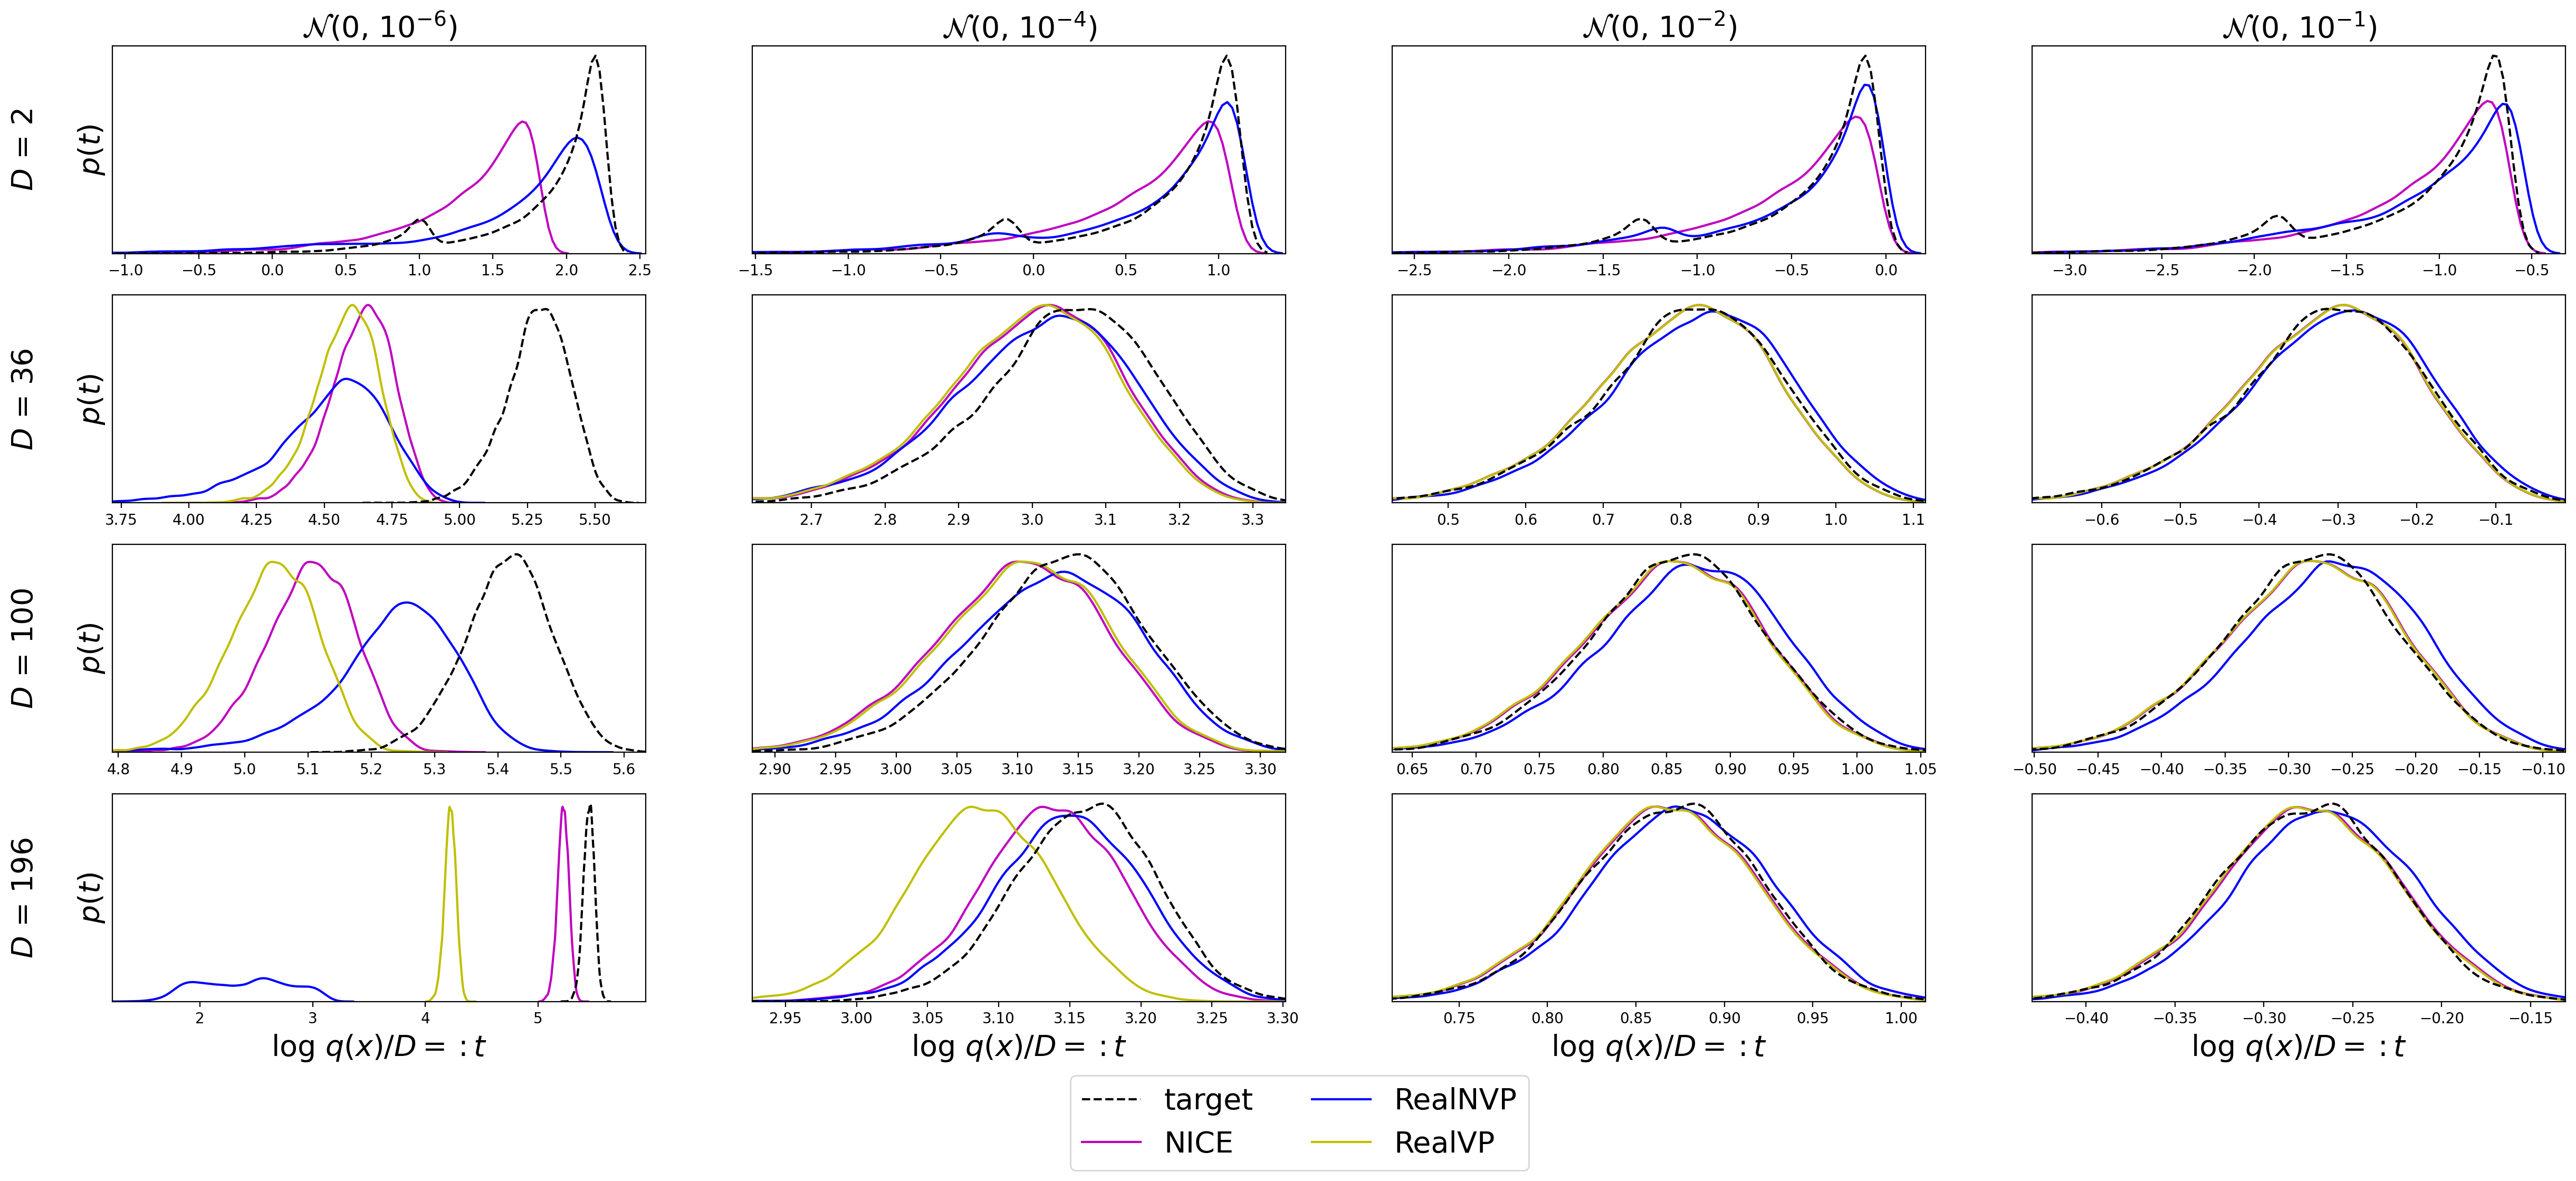

In [57]:
plot_all_data('state_density', quantile_alpha=0.01, save_path=used_folder + 'state_density')

plotting


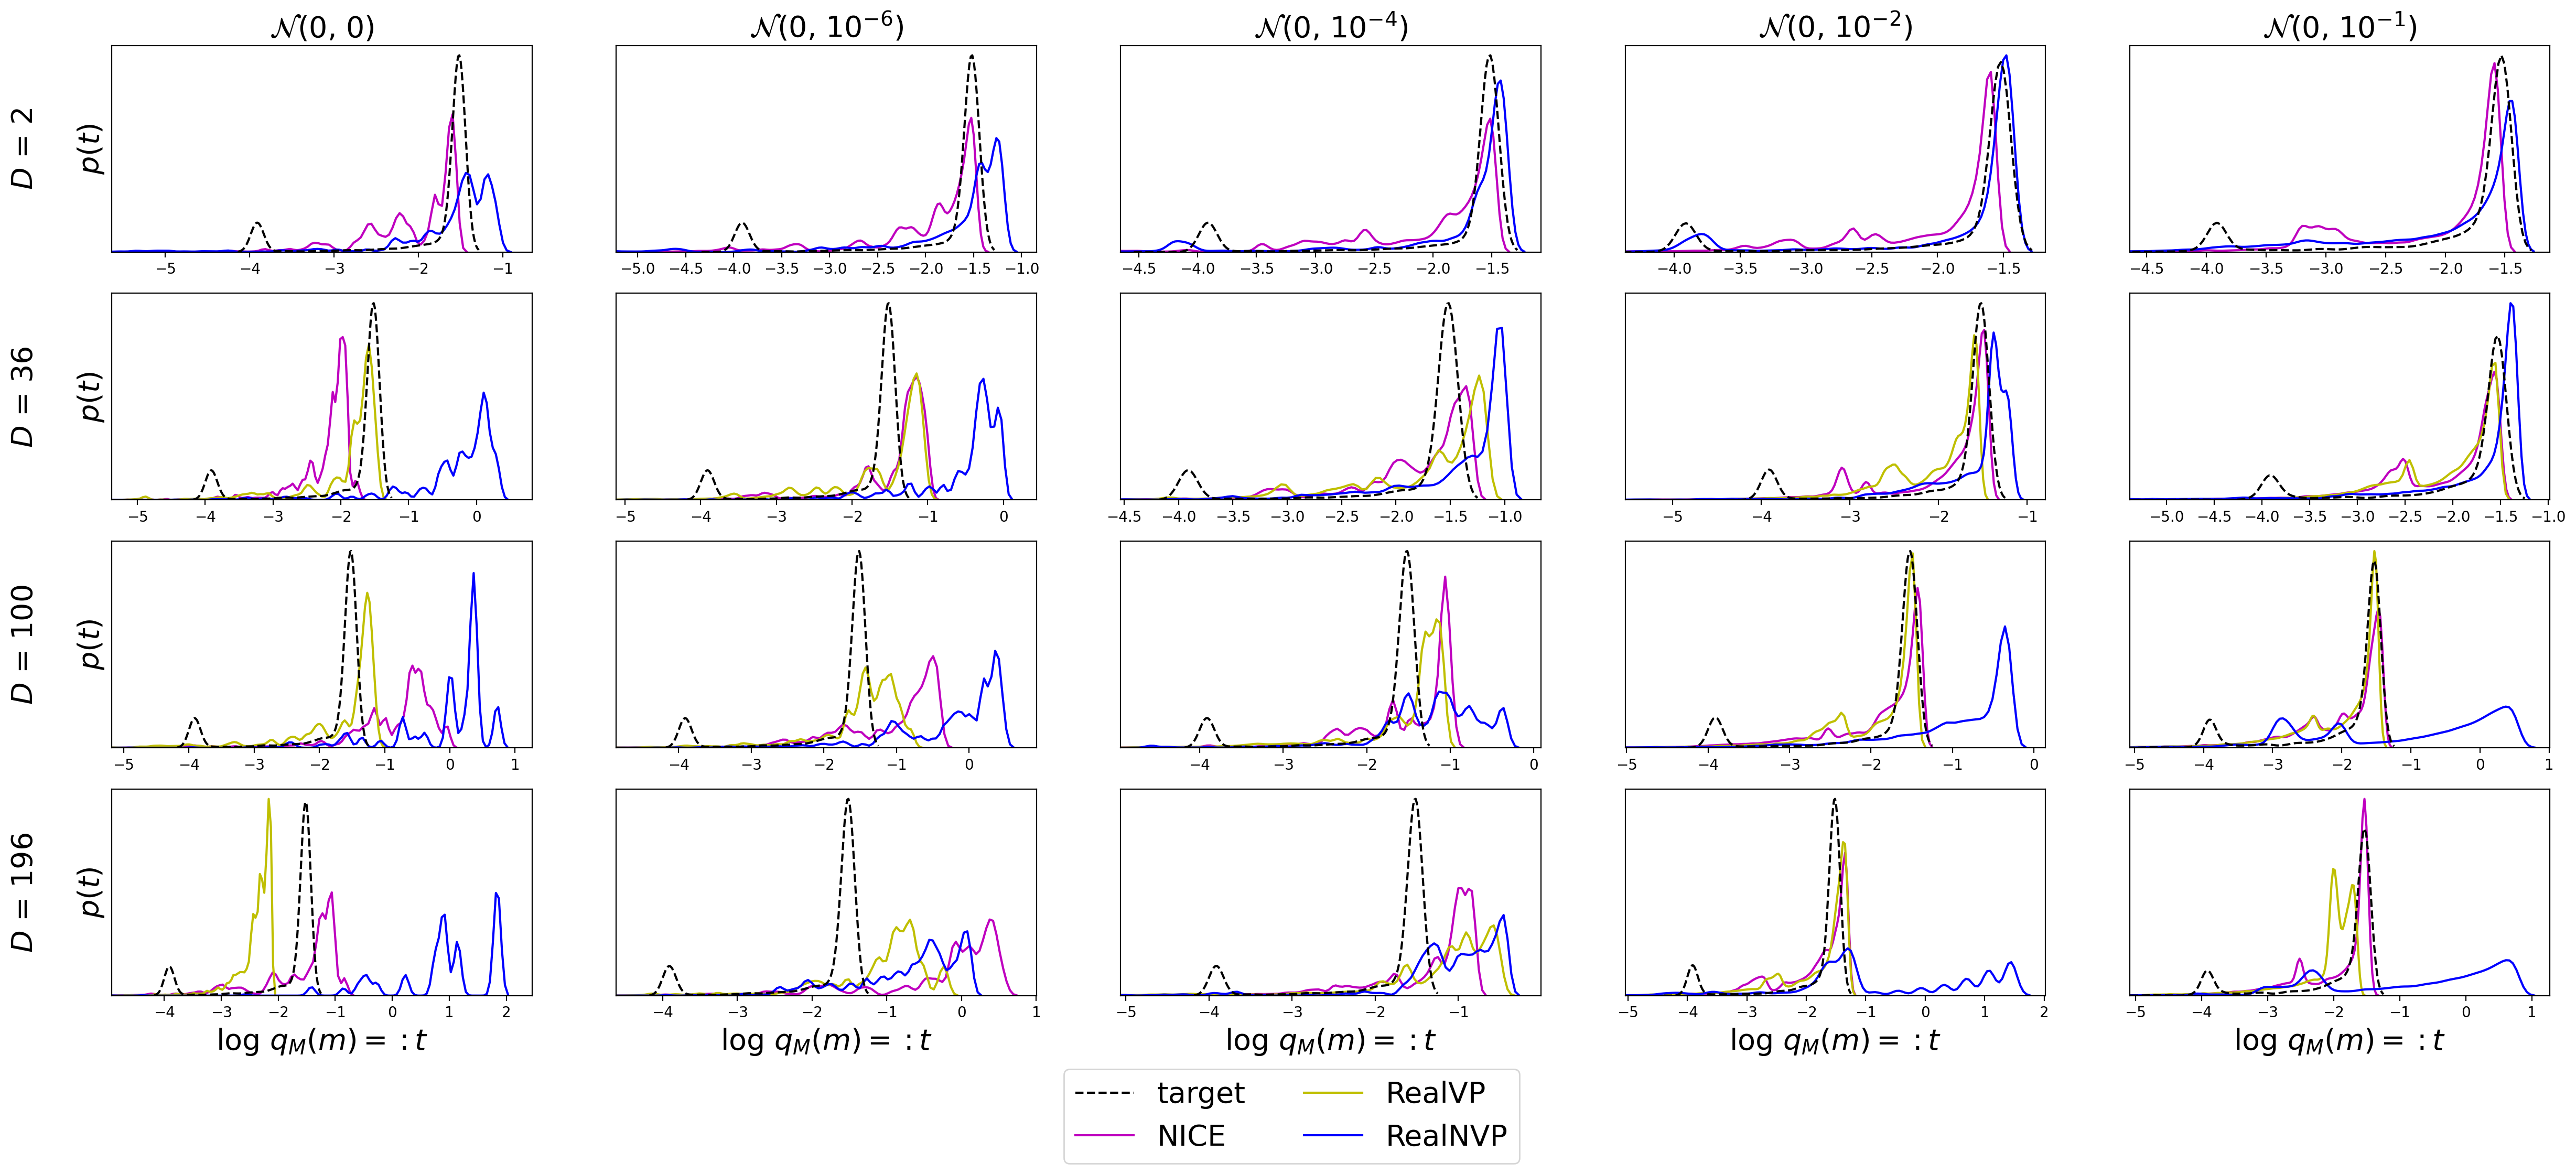

In [55]:
plot_all_data('dos_manifold', quantile_alpha=0.01, save_path=used_folder + 'dos_manifold')

In [579]:
#plot_all_data(PD_IDX, quantile_alpha=0.01, save_path='log_likelihood')

We cut off at a certain quantile. <br>
"prior" is the N(0,1) with the respective dimensionality - not visible prior lines are intended as they would distort the plot<br>
"true" is the true distribution - not that it different to the prior as most of it comes from: N(0,var).

#### Working Deflation

$\int q(x) dx = \int q(x) \frac{p(x)}{p(x)} dx \approx \frac{1}{N} \sum \frac{q(x)}{p(x)}$ <br>
$\int \left( \sum \frac{q(x)}{p(x)} \right)^{-1} q(x) dx \approx 1$ <br>
exp_vals = q - true_p
logged_norm_const = - np.log(len(exp_vals)) + logsumexp(exp_vals)
return q - logged_norm_const

In [580]:
#%matplotlib qt / inline
#plot_all_data(CORRECTED_PD, quantile_alpha=0.01, save_path='state_dense_corrected')

#### What the Models predicted

In [581]:
#plot_all_data(PD_IDX, quantile_alpha=0.01, save_path='state_dense')

#### Centered densities

In [582]:
#plot_all_data(T_SCORE, quantile_alpha=0.01, save_path='state_dense_t_score')

In [583]:
#plot_all_data(PD_IDX, quantile_alpha=0.01, save_path='state_dense', prior_inflation_adjustment=True)

# Real Distribution
M ~ Manifold<br>
E ~ N(0, var)<br>
<br>
Z = [M+E, 0, ..., 0]<br>
X = rotate(Z)<br>
<br>
Looking at: <br>
q_x(X)

emb(m) embeds m in X
carefull when using this with uniform noise


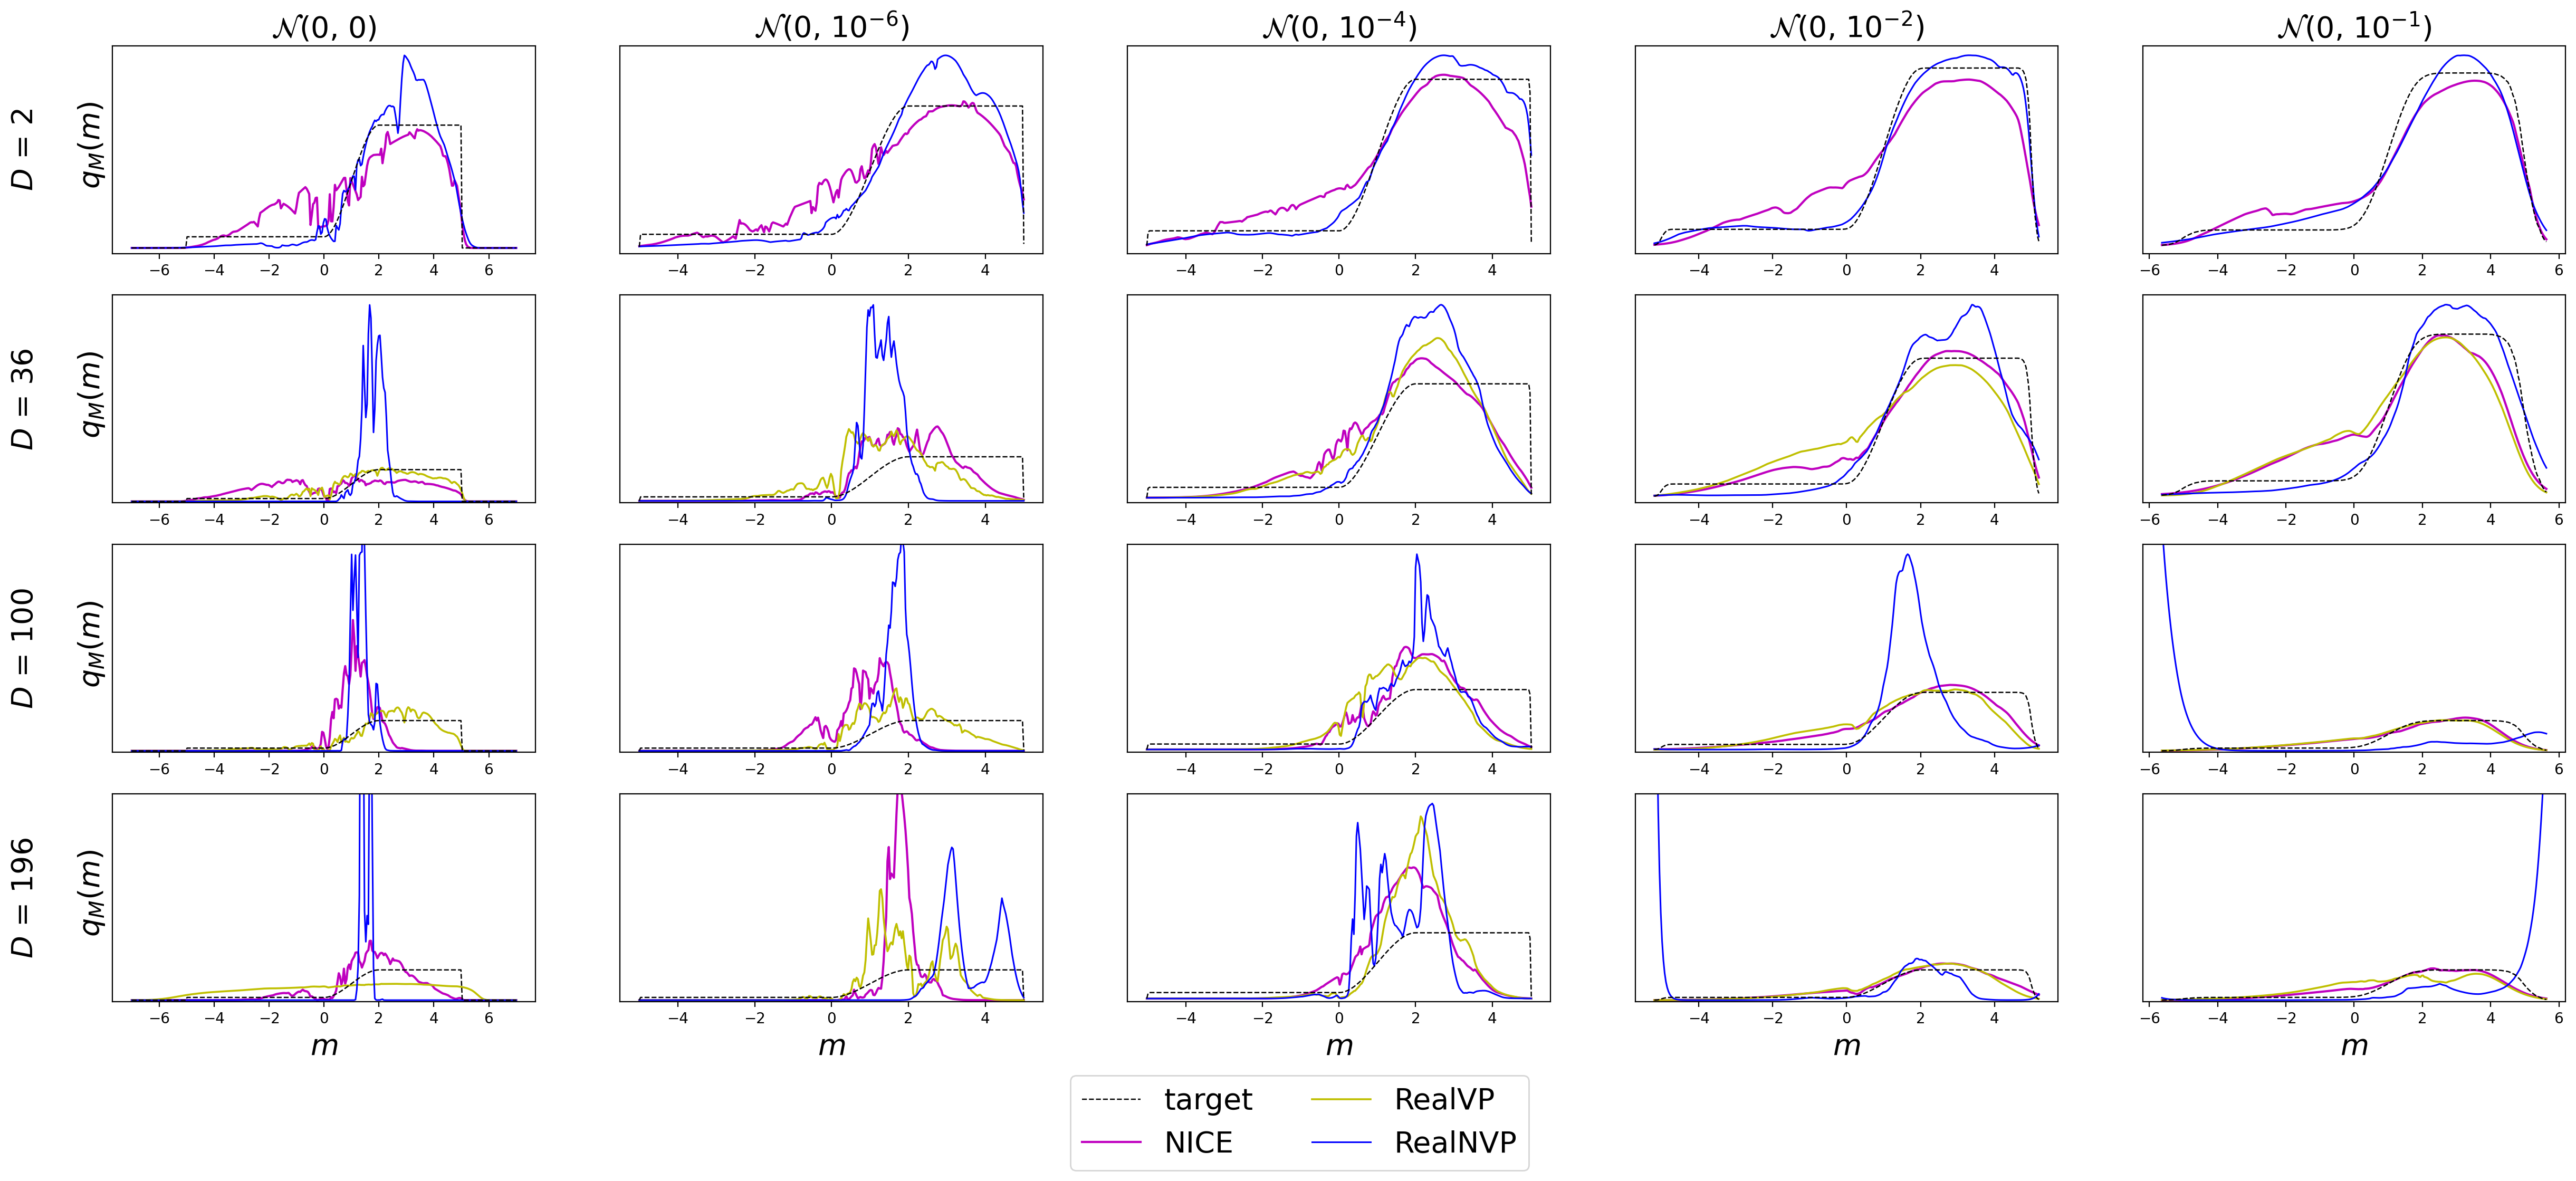

In [584]:
def plot_pdf(idx, quantile_alpha=0.05, logged=False, save_path=None):
    gauss_data = config.dataset == 'gauss'
    fig, axs = plt.subplots(nrows=len(dimensions), ncols=len(variances), squeeze=False, figsize=(30, 3*len(dimensions)), dpi=200)
    for iD, dim in enumerate(dimensions):
        for iS, var in enumerate(variances):
            #if not (dim == 36 and var == 1e-4):
            #    continue
                
            ax = axs[iD, iS]
            
            #if not logged:
            #    ax.set_yscale('log')
            
            #print(model, dim, var)
            if iD == 0:
                ax.set_title(f'{gauss_symbol()}(0, {var_to_label(var)})', size=20)
            if iS == 0:
                sdim = int(np.sqrt(dim))
                log_test = 'log' if logged else ''
                ax.set_ylabel(f'$D$ = {dim}\n\n {log_test}'+ '$q_M(m)$', size=20)
            else:
                ax.set_ylabel('')

            if iD == len(dimensions)-1:
                ax.set_xlabel('$m$', size=20)

            m = all_models['true'][dim][var]['manifold_grid']['dataset'].data[INFLATED_MANIFOLD_DATA]
            all_scores = []
            for iModel, model in enumerate(MODEL_SORTING):
                if model == 'RealVP' and dim == 2: continue  # coincides with NICE
                assert 'uniform' not in model
                model_data = all_models[model]
                llh = model_data[dim][var]['manifold_grid'][idx]
                if not logged:
                    llh = np.exp(llh)
                    #print(np.sum(llh))
                line_style = '--' if model == 'true' else '-'
                linewidth = 1.5 - 0.2 * iModel # s.t. one can see overlying lines
                
                label = model if model != 'true' else 'target'
                ax.plot(m, llh, line_style, linewidth=linewidth, color=get_model_color(model), label=label)
                if model != 'true':
                    all_scores += [*llh]
                #if model == 'NICE':
                #    print(llh[np.logical_and(m > -0.25, m < 0.25)])
            # cut off really small values
            all_scores = np.sort(all_scores)
            if logged: 
                bottom = all_scores[int(len(all_scores) * 0.05)]
                if bottom < -50:
                    ax.set_ylim(bottom=bottom)
            else:
                ax.set_ylim(bottom=0)
                
            top = all_scores[int(len(all_scores) * 0.99)]
            if all_scores.max() > 1.5 and not gauss_data:
                ax.set_ylim(top=1.5)
            if not logged:
                ax.set_ylim(bottom=-0.01)
                if not gauss_data:
                    ax.set_yticks([])
            
    handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='lower center')    
    #print(type(handles))
    #print(handles)
    handles.insert(0, handles[-1]), labels.insert(0, labels[-1]), 
    handles.pop(-1), labels.pop(-1)
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=20, bbox_to_anchor=(0.5, -0.02))
        
    #fig.legend()
    #fig.tight_layout()
    #plt.suptitle(f'{DATASET_NAME}', fontweight='bold', size=22, y=1 if len(dimensions) > 1 else 1.2)
    save_inflation_fig(fig, save_path, config.dataset, dimensions, DATASET_EXTENSION)
    print('emb(m) embeds m in X')
    print('carefull when using this with uniform noise')

#plot_pdf(PD_IDX, logged=False)
plot_pdf(CORRECTED_PD, logged=False, save_path=used_folder+'pdf')

In [585]:
#plot_pdf(PD_IDX, logged=False, save_path='pdf')

In [586]:
#if dimensions[0] < 10:
    #plot_pdf(PD_IDX, logged=False, save_path='pdf')

In [587]:
#error!
 #intentially

# Jacobian
---------


PDF of multivariate centered Guass:<br>
$p(x) := (2 \pi)^{-\frac{\dim}{2}} \det(\Sigma)^{-\frac{1}{2}} \exp \left( -\frac{1}{2} x^T \Sigma^{-1} x \right)$<br>
$\log p(x) =  -\frac{\dim}{2} \log(2 \pi) -\frac{1}{2} \log \det(\Sigma) -\frac{1}{2} x^T \Sigma^{-1} x$<br>

The mean of $\log(V(x))$ is approximately where $\frac{1}{2}\left(-\frac{1}{2} \log \det(\Sigma) \right)$ = $-\frac{1}{2} log(\sigma) \cdot \dim$<br>
Exponentiated: $\det(\Sigma)^\frac{1}{4}$

In [588]:
def log_volume_change_prediction(var):
    SIZE = 1000
    scale = np.sqrt(var)
    x = norm.rvs(scale=scale, size=SIZE)
    x = np.double(x)
    v = -np.log(scale) + 1/2 * x**2 * (1 - 1/var)
    return v


def plot_volume_changes():
    fig, axs = plt.subplots(nrows=len(dimensions), ncols=1, squeeze=False, figsize=(20, len(dimensions)*3), dpi=100, sharex=True)
    axs = axs.flatten()
    y_log = False
    for iD, dim in enumerate(dimensions):
        ax = axs[iD]
        ax.set_ylabel(f'dim($x$) = {dim} \n\n$p( y )$', size=15)
        for iS, var in enumerate(variances):
            #print(model, dim, var)
            color = sns.color_palette("tab10")[iS]

            # RealNVP
            volumes = all_models['RealNVP'][dim][var]['ambient']['volume']
            volumes = volumes / dim
            sns.distplot(volumes, label=f'$σ^2$ = {var_to_label(var)}', #  | Mean RealNVP: {volumes.mean():.1f} 
                         hist=False, color=color, ax=ax, kde_kws={'bw_adjust': 1, 'linewidth': 0.8})

            # NICE
            scaling = all_models['NICE'][dim][var]['ambient']['volume'][0]  # is constant for all samples
            ax.axvline(scaling / dim, color=color, linestyle='--')

            # Res Flow
            if RES_FLOW_CONTAINED:
                volumes = -all_models['ResFlow'][dim][var]['ambient']['volume']
                volumes = volumes / dim
                sns.distplot(volumes, hist=False, color=color, ax=ax, kde_kws={'bw_adjust': 1, 'linewidth': 0.8, 'linestyle': 'dashdot'})

            # prediction
            if var > 0 and (dim != 2 or DATASET_NAME == 'Gauss'):
                #continue
                ax.axvline(-np.log(np.sqrt(var)), color=color, linewidth=2, linestyle='dotted')
                """if var == 1: # then this is dirac
                    ax.axvline(-np.log(np.sqrt(var)), color=color, linewidth=2, linestyle='dotted')
                else:
                    #sampled_prediction = log_volume_change_prediction(var)
                    #sns.distplot(sampled_prediction, color=color, ax=ax, kde=True, 
                    #             kde_kws={'bw_adjust': 0.5, 'linestyle': 'dotted'}, hist=False, norm_hist=True)
                """
    # Legend stuff
    nice_legend = Line2D([0], [0], label='NICE Scaling', color='k', linestyle='--')
    realnvp_legend = Line2D([0], [0], label='RealNVP V(x)', color='k')
    prediction_legend = Line2D([0], [0], label='Prediction', color='k', linestyle='dotted')

    if RES_FLOW_CONTAINED:
        resflow_legend = Line2D([0], [0], label='ResFlow V(x)', color='k', linestyle='dashdot')
    #prediction_histo_legend = Line2D([0], [0], label='Predict. Histo', color='k', linewidth=5)

    handles, labels = ax.get_legend_handles_labels()
    handles.extend([nice_legend, realnvp_legend, prediction_legend])
    if RES_FLOW_CONTAINED:
        handles.extend([resflow_legend])
    fig.legend(handles=handles, loc='center right')

    # Limit Stufff
    xlims = np.array([ax.get_xlim() for ax in axs])
    xlim_min, xlim_max = xlims.min(axis=0)[0], xlims.max(axis=0)[1]
    tick_positions = np.arange(np.ceil(2 * xlim_min)/2, xlim_max, 0.25)
    tick_lables = [int(tick) if int(tick) == tick else '' for i, tick in enumerate(tick_positions)]

    for ax in axs:
        ax.xaxis.set_tick_params(which='both', labelbottom=True)
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_lables)
        ax.set_yticks([])

        if not RES_FLOW_CONTAINED:
            if DATASET_NAME == 'Uniform':
                ax.set_xlim([-0.25, 8])
            if DATASET_NAME in ['Smooth Step', 'von Mises']:
                ax.set_xlim([-0.25, 7])
        if ax.get_ylim()[1] > 50:
            ...
            ax.set_ylim(top=50)

    axs[-1].set_xlabel('log( V(x) ) / dim(x) =: y', size=15)
    axs[0].set_title(f'{DATASET_NAME} | Volume Changes', size=18, fontweight='bold')

    save_inflation_fig(fig, 'volume', config.dataset, dimensions, DATASET_EXTENSION)

    print('No prediction for Dim=2 as the prediction is too bad due to actual differing state density')

#plot_volume_changes()
_=_

-----------
# Plot Jacobian along Manifold

In [589]:
def plot_jacobian_along_manifold(quantile_alpha=0.05, save_path=None):
    logged = True
    fig, axs = plt.subplots(nrows=len(dimensions), ncols=len(variances), squeeze=False, figsize=(30, 3*len(dimensions)), dpi=200)
    for iD, dim in enumerate(dimensions):
        for iS, var in enumerate(variances):
            ax = axs[iD, iS]
            
            #print(model, dim, var)
            if iD == 0 and config.dataset != 'gauss':
                ax.set_title(f'{gauss_symbol()}(0,{var_to_label(var)})', size=20)
            if iS == 0:
                sdim = int(np.sqrt(dim))
                log_test = 'log' if logged else ''
                ax.set_ylabel(f'$D$ = {dim}\n\n {log_test} $q$( emb($z$) )', size=20)
            else:
                ax.set_ylabel('')

            if iD == len(dimensions)-1:
                ax.set_xlabel('z', size=20)
            
            model_data = all_models['RealNVP']
            data_index = 'ambient'
            
            #z = all_models['true'][dim][var][data_index][MANIFOLD_DATA_WITH_NOISE].squeeze(1)
            z = model_data[dim][var][data_index][Z_IDX][:, 3]
            #print(z.shape)
            z_sort = np.argsort(z)
            z = z[z_sort]
            all_scores = []
            
            llh = model_data[dim][var][data_index][VOLUME_IDX][z_sort]
            if not logged:
                llh = np.exp(llh)
            #line_style = '--' if model == 'true' else '-'
            line_style = '-' # get_model_color(model)
            ax.plot(z, llh, line_style, color='k', label='k')
            #if model != 'true':
            #    all_scores += [*llh]

            # cut off really small values
            """
            all_scores = np.sort(all_scores)
            if logged: 
                bottom = all_scores[int(len(all_scores) * 0.05)]
                if bottom < -50:
                    ax.set_ylim(bottom=bottom)
            else:
                ax.set_ylim(bottom=0)
                
            top = all_scores[int(len(all_scores) * 0.99)]
            if all_scores.max() > 1.5:
                ax.set_ylim(top=1.5)
            if not logged:
                ax.set_ylim(bottom=-0.01)
                ax.set_yticks([])
            """
    #handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='lower center')
    #fig.legend()
    #fig.tight_layout()
    #plt.suptitle(f'{DATASET_NAME} | {index_to_name(idx)}', size=22, y=1 if len(dimensions) > 1 else 1.2)
    #save_inflation_fig(fig, save_path, DATASET_NAME, dimensions, DATASET_EXTENSION)
    print('emb(z) embeds z in X')

#plot_pdf(CORRECTED_PD, logged=False)

#plot_jacobian_along_manifold()

Let $x$ be a sample of the data. <br>
$f: X \rightarrow Z$ is the transformation from the data space to the latent space. <br>
$p_x(x)$ is the true density of $x$ and $p_N(f(x))$ is the density of $f(x)$ meassured with the <i>prior</i>.<br>
<br>
To obtain the correct density of $x$, the density needs to be adjusted with some volume change $v(x)$ like<br>
$p_x(x) = v_f(x) \; p_z(f(x))$. <br>
Thus the expected volume change is: $v_f(x) = \frac{p_x(x)}{p_z(f(x))}$.<br>
As this is most interesting along the embedded manifold, <br>
we plot the expected volume change and the actual volume change along the manifold.

plotting


NameError: name 'text_size' is not defined

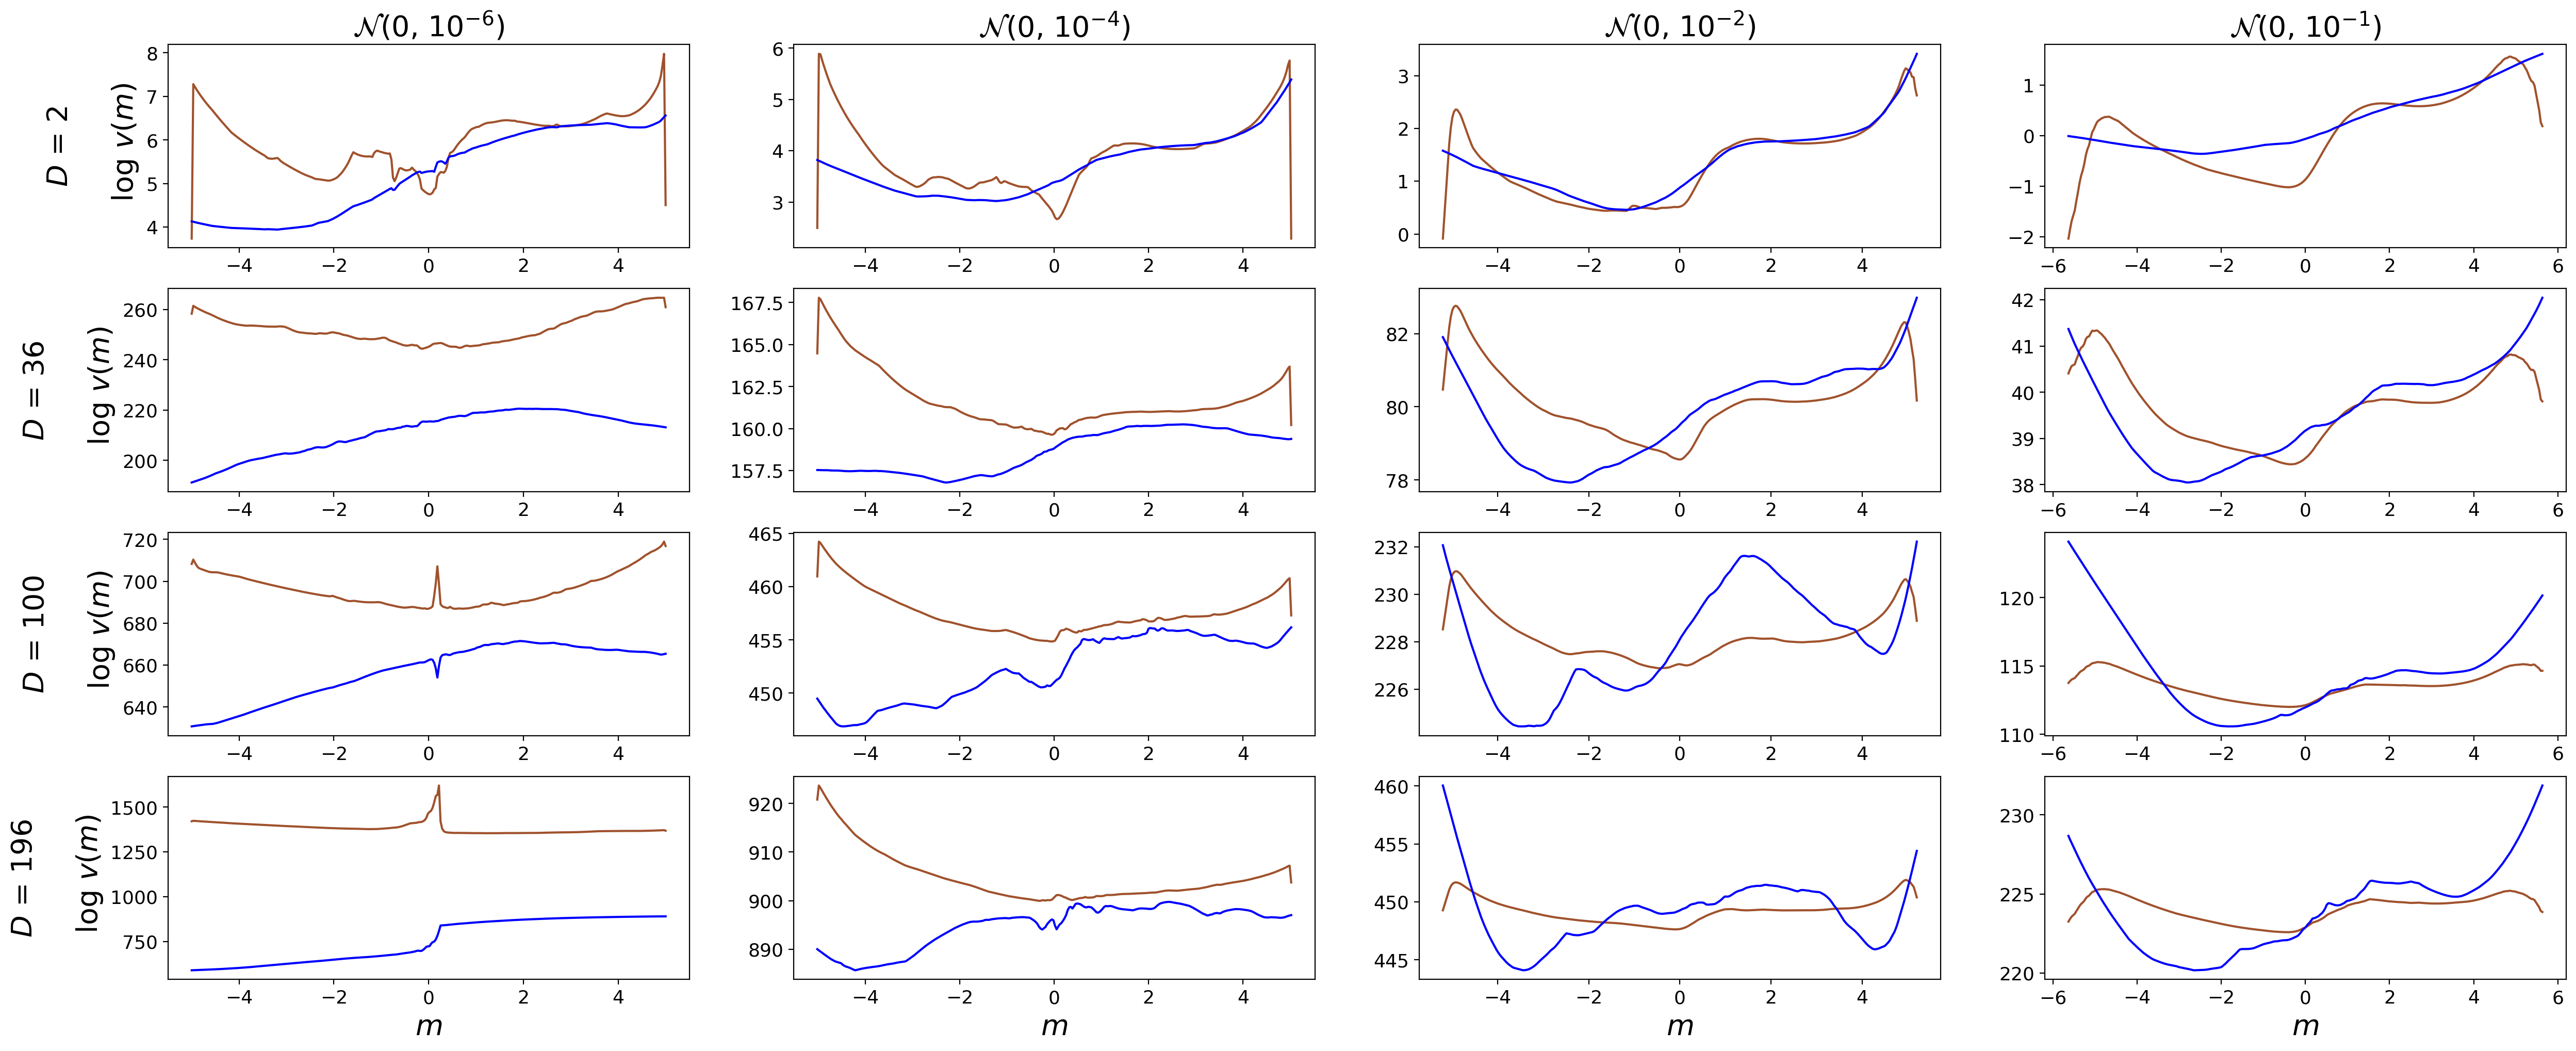

In [326]:
def plot_volume_changes():
    # this is not interpretable
    used_var = variances[variances != 0]
    fig, axs = plt.subplots(nrows=len(dimensions), ncols=len(used_var), squeeze=False, figsize=(30, 3*len(dimensions)), dpi=200)
    logged = True
    for iD, dim in enumerate(dimensions):
        for iS, var in enumerate(used_var):
            ax = axs[iD, iS]
            
            ax.tick_params(axis='both', which='major', labelsize=13)
            if iD == 0:
                ax.set_title(f'{gauss_symbol()}(0, {var_to_label(var)})', size=20)
            if iS == 0:
                sdim = int(np.sqrt(dim))
                log_test = 'log' if logged else ''
                ax.set_ylabel(f'$D$ = {dim}\n\n {log_test} $v(m)$', size=20)
            else:
                ax.set_ylabel('')

            if iD == len(dimensions)-1:
                ax.set_xlabel('$m$', size=20)

            manifold_points = all_models['true'][dim][var]['manifold_grid']['dataset'].data[INFLATED_MANIFOLD_DATA]
            
            actual_volume = all_models['RealNVP'][dim][var]['manifold_grid'][VOLUME_IDX]
            prior_llh = all_models['RealNVP'][dim][var]['manifold_grid'][NO_VOLUME_PD]
            true_pd = all_models['true'][dim][var]['manifold_grid']['dataset'].densities[FULL_INFLATED_LOG_PD]
            
            expected_volume_change = true_pd - prior_llh
            ax.plot(manifold_points, expected_volume_change, label='optimal volume element', color='sienna')
            ax.plot(manifold_points, actual_volume, label='actual volume element', color=get_model_color('RealNVP'))
            #if not logged:
            #    llh = np.exp(llh)
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', prop={'size': 18}, bbox_to_anchor=(0.51, -0.02))
    
    #plt.suptitle(f'{DATASET_NAME}', size=22, fontweight='bold', y=1 if len(dimensions) > 1 else 1.2)
    save_inflation_fig(fig, used_folder+'volume_changes', config.dataset, dimensions, DATASET_EXTENSION)
    print('emb(m) embeds m in X')

print('plotting')
plot_volume_changes()